成功加载本地 DeepGPR 包: /home/ll/cpudeepgpr/test/DeepGPR-dev/src/DeepGPR/__init__.py


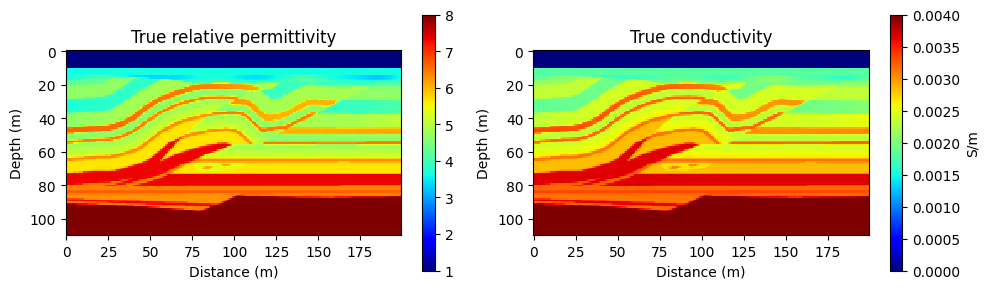

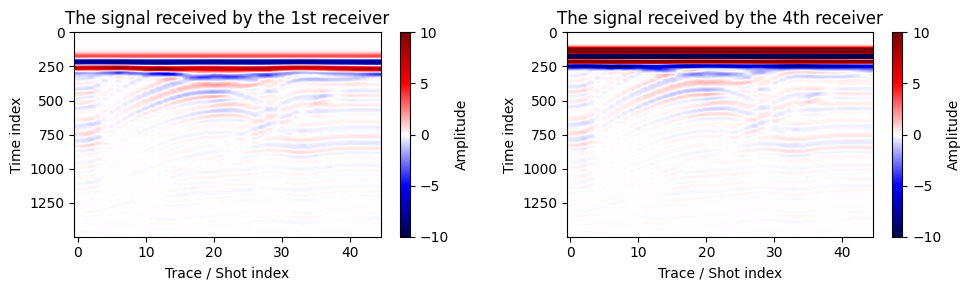

In [1]:

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from skimage import filters
import time
import numpy as np
import sys
from pathlib import Path

fixed_src_path = Path("/home/ll/cpudeepgpr/test/DeepGPR-dev/src").resolve()

# 验证一下路径是否存在，防止写错路径导致报错
if not (fixed_src_path / "DeepGPR" / "__init__.py").exists():
    raise FileNotFoundError(
        f"指定的路径无效，找不到 DeepGPR 包:\n{fixed_src_path / 'DeepGPR'}\n"
        "请检查路径是否正确。"
    )

# 确保该路径在 sys.path 的最前面，且没有重复
src_str = str(fixed_src_path)
if src_str in sys.path:
    sys.path.remove(src_str)
sys.path.insert(0, src_str)
# --- 修改部分结束 ---

import DeepGPR

# 验证加载的来源是否正确
loaded_package = Path(DeepGPR.__file__).resolve()
if not str(loaded_package).startswith(str(fixed_src_path)):
    raise RuntimeError(
        f"错误: DeepGPR 依然是从旧位置加载的: {loaded_package}\n"
        f"期望从: {fixed_src_path} 加载\n"
        "请尝试重启 Kernel (Restart Kernel) 后再次运行。"
    )

print(f"成功加载本地 DeepGPR 包: {loaded_package}")

# 设置设备
if torch.cuda.is_available():
    device = torch.device("cuda:6")
else:
    device = torch.device("cpu")
    print("未检测到 CUDA，使用 CPU")

dx=0.02
dt=2e-11
nt=1500
nshots=45

source_location=torch.zeros((nshots,1,3),device=device,dtype=torch.int)
source_location[:,0,0]=50
source_location[:,0,1]=10
source_location[:,0,2]=torch.arange(10, 190, 4)

receiver_location = torch.zeros((nshots, 12, 3),device=device, dtype=torch.int)
receiver_location[:, :, 0] = torch.tensor([20, 25,30,35, 40,45,55, 60,65, 70,75, 80], device=device).repeat(45,1)
receiver_location[:, :, 1] = 10
receiver_location[:, :, 2] = torch.arange(11, 191, 4).repeat(12,1).transpose(0, 1)

freq=5e8
peak_time = 1 / 3e8
source_amplitudes = torch.zeros((1,nt,1),device=device)
source_amplitudes[0,:,0]=DeepGPR.ricker(freq, nt, dt, peak_time).to(device)

ert=torch.tensor(np.load('OverThrust.npy')[::2,::2], dtype=torch.float32, device=device).repeat(100,1,1)
ert = torch.cat([torch.ones(ert.shape[0], 10, ert.shape[2], device=ert.device, dtype=ert.dtype),ert], dim=1)
set=ert.clone()*0.0005
ert[:,:11,:]= 1
set[:,:11,:]= 0

fig, axes = plt.subplots(1, 2, figsize=(10, 3))  
im1 = axes[0].imshow(ert[50, :, :].cpu().numpy(),
                     cmap='jet',
                     interpolation='nearest',
                     aspect='equal')
cbar1 = plt.colorbar(im1, ax=axes[0])
axes[0].set_title('True relative permittivity')
axes[0].set_xlabel('Distance (m)')
axes[0].set_ylabel('Depth (m)')
im2 = axes[1].imshow(set[50, :, :].cpu().numpy(),
                     cmap='jet',
                     interpolation='nearest',
                     aspect='equal')
cbar2 = plt.colorbar(im2, ax=axes[1])
cbar2.set_label('S/m')
axes[1].set_title('True conductivity')
axes[1].set_xlabel('Distance (m)')
axes[1].set_ylabel('Depth (m)')
plt.tight_layout()
plt.show()

pershot=1
#Forward modeling
r_obs_list = []
for i in range(nshots//pershot):
    r = DeepGPR.compute(
        device=device, dx=dx, dt=dt, 
        source_amplitudes=source_amplitudes,
        source_location=source_location[i*pershot:(i+1)*pershot,:,:], 
        receiver_location=receiver_location[i*pershot:(i+1)*pershot,:,:], 
        er=ert, se=set, model_gradient_sampling_interval=3, mode=3,wavefield_storage_dtype=torch.float16
    )
    r_obs_list.append(r[-1])
r_obs = torch.cat(r_obs_list, dim=0)


fig, axes = plt.subplots(1, 2, figsize=(10, 3))
im0 = axes[0].imshow(
    r_obs[:, :, 3].detach().cpu().numpy().T,
    cmap='seismic',
    origin='upper',
    aspect='auto',
    vmax=10,
    vmin=-10
)
axes[0].set_title("The signal received by the 1st receiver")
axes[0].set_xlabel("Trace / Shot index")
axes[0].set_ylabel("Time index")
fig.colorbar(im0, ax=axes[0], label='Amplitude')
im1 = axes[1].imshow(
    r_obs[:, :, 5].detach().cpu().numpy().T,
    cmap='seismic',
    origin='upper',
    aspect='auto',
    vmax=10,
    vmin=-10
)
axes[1].set_title("The signal received by the 4th receiver")
axes[1].set_xlabel("Trace / Shot index")
axes[1].set_ylabel("Time index")
fig.colorbar(im1, ax=axes[1], label='Amplitude')
plt.tight_layout()
plt.show()



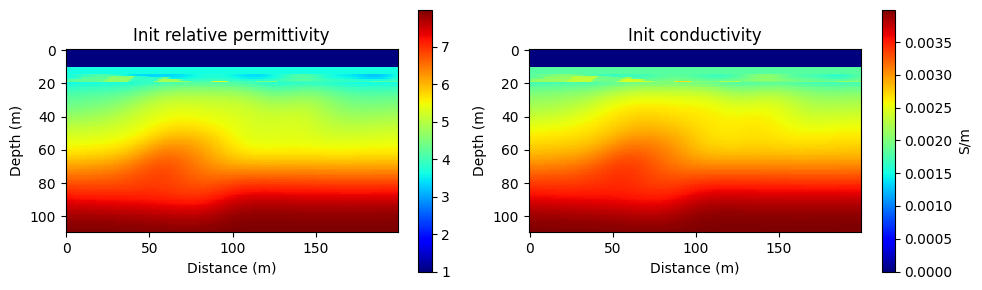

Stage 1: er lr=1.00e-02
Stage 2: er lr=5.00e-03, se lr=1.00e-04


In [2]:

# ============================================================
# 反演模型初始化
# ============================================================

er = torch.tensor(
    filters.gaussian(
        ert.detach().cpu().numpy(),
        sigma=10,
    ),
    dtype=torch.float32,
    device=device,
)

se = torch.tensor(
    filters.gaussian(
        set.detach().cpu().numpy(),
        sigma=10,
    ),
    dtype=torch.float32,
    device=device,
)

# 保持近地表部分为真实模型，避免空气层和近地表被更新破坏
with torch.no_grad():
    er[:, :20, :] = ert[:, :20, :]
    se[:, :20, :] = set[:, :20, :]

er.requires_grad_(True)
se.requires_grad_(False)


# ============================================================
# 优化器
#
# 原代码中的 se 学习率 0.2 相对于 1e-3 量级的电导率过大，
# 联合反演阶段容易直接把 se 推到非物理范围。
# ============================================================

ER_LR_STAGE1 = 1.0e-2
ER_LR_STAGE2 = 5.0e-3
SE_LR_STAGE2 = 1.0e-4

optimizer1 = torch.optim.Adam([
    {
        "params": [er],
        "lr": ER_LR_STAGE1,
    },
])

optimizer2 = torch.optim.Adam([
    {
        "params": [er],
        "lr": ER_LR_STAGE2,
    },
    {
        "params": [se],
        "lr": SE_LR_STAGE2,
    },
])

optimizer = optimizer1


# ============================================================
# 损失和训练配置
# ============================================================

losses = []
n_epochs = 111

loss_fnmse = torch.nn.MSELoss()
loss_fnl1 = torch.nn.L1Loss()

start_time = time.time()

tv_criterion = DeepGPR.TVRegularization(
    weight_ep=20,
    weight_sigma=0.0001,
).to(device)


# ============================================================
# 初始模型显示
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(10, 3))

im1 = axes[0].imshow(
    er[50, :, :].detach().cpu().numpy(),
    cmap="jet",
    interpolation="nearest",
    aspect="equal",
)
plt.colorbar(im1, ax=axes[0])
axes[0].set_title("Init relative permittivity")
axes[0].set_xlabel("Distance (m)")
axes[0].set_ylabel("Depth (m)")

im2 = axes[1].imshow(
    se[50, :, :].detach().cpu().numpy(),
    cmap="jet",
    interpolation="nearest",
    aspect="equal",
)
cbar2 = plt.colorbar(im2, ax=axes[1])
cbar2.set_label("S/m")
axes[1].set_title("Init conductivity")
axes[1].set_xlabel("Distance (m)")
axes[1].set_ylabel("Depth (m)")

plt.tight_layout()
plt.show()

print(
    f"Stage 1: er lr={ER_LR_STAGE1:.2e}\n"
    f"Stage 2: er lr={ER_LR_STAGE2:.2e}, "
    f"se lr={SE_LR_STAGE2:.2e}"
)


## 数值稳定性诊断版训练

本单元会在每个炮的数据反传、TV 反传、梯度加权、梯度裁剪和 Adam 更新后检查 NaN/Inf。首次抛出的阶段即为最早出现数值异常的位置。

运行前请先执行 **Restart Kernel and Run All Cells**，避免旧模型参数或旧 Adam 状态残留。


In [3]:

import math
import time
import torch
import matplotlib.pyplot as plt


# ============================================================
# 调试和稳定性配置
# ============================================================

AIR_DEPTH = 15
TAPER_TRANSITION = 5

# TV 梯度范数相对于数据梯度范数的比例
TV_RATIO_ER = 0.10
TV_RATIO_SE = 0.08

# 反演阶段先使用 float32 保存波场。
# 如果本文件能够运行，而改回 float16 后报错，
# 则基本可以确定问题来自 float16 波场存储/反传溢出。
WAVEFIELD_STORAGE_DTYPE = torch.float32

# True 会给出更详细的 autograd 报错栈，但运行会明显变慢。
DETECT_ANOMALY = False

# 梯度裁剪只处理“数值有限但过大”的梯度。
# NaN/Inf 会在裁剪之前被 require_finite 拦截。
ENABLE_GRAD_CLIPPING = True
MAX_GRAD_NORM = 100.0

# 较宽的物理范围约束，防止单次更新把模型推到极端值。
ER_MIN = 1.0
ER_MAX = 30.0
SE_MIN = 0.0
SE_MAX = 0.05

EPS_NORM = 1.0e-30


# ============================================================
# 数值检查工具
# ============================================================

def tensor_statistics(tensor):
    """返回张量的有限性、范围和 float64 范数统计。"""
    if tensor is None:
        return {
            "is_none": True,
            "numel": 0,
            "finite": 0,
            "nan": 0,
            "inf": 0,
            "min": float("nan"),
            "max": float("nan"),
            "absmax": float("nan"),
            "norm": float("nan"),
        }

    value = tensor.detach()
    finite_mask = torch.isfinite(value)

    nan_count = int(torch.isnan(value).sum().item())
    inf_count = int(torch.isinf(value).sum().item())
    finite_count = int(finite_mask.sum().item())

    if finite_count > 0:
        finite_values = value if finite_count == value.numel() else value[finite_mask]
        finite_values64 = finite_values.to(torch.float64)

        finite_min = float(finite_values64.min().item())
        finite_max = float(finite_values64.max().item())
        finite_absmax = float(finite_values64.abs().max().item())
        finite_norm = float(
            torch.linalg.vector_norm(finite_values64).item()
        )
    else:
        finite_min = float("nan")
        finite_max = float("nan")
        finite_absmax = float("nan")
        finite_norm = float("nan")

    return {
        "is_none": False,
        "numel": value.numel(),
        "finite": finite_count,
        "nan": nan_count,
        "inf": inf_count,
        "min": finite_min,
        "max": finite_max,
        "absmax": finite_absmax,
        "norm": finite_norm,
    }


def format_statistics(name, tensor):
    stats = tensor_statistics(tensor)

    if stats["is_none"]:
        return f"{name}: None"

    return (
        f"{name}: "
        f"shape={tuple(tensor.shape)}, "
        f"dtype={tensor.dtype}, "
        f"device={tensor.device}, "
        f"finite={stats['finite']}/{stats['numel']}, "
        f"NaN={stats['nan']}, "
        f"Inf={stats['inf']}, "
        f"min={stats['min']:.6e}, "
        f"max={stats['max']:.6e}, "
        f"absmax={stats['absmax']:.6e}, "
        f"norm64={stats['norm']:.6e}"
    )


def require_finite(name, tensor, epoch=None, shot=None):
    """
    发现 NaN/Inf 后立即终止，并给出最先出错的 epoch、炮号和阶段。
    """
    location = []

    if epoch is not None:
        location.append(f"epoch={epoch}")

    if shot is not None:
        location.append(f"shot={shot}")

    location_text = ", ".join(location)
    statistics_text = format_statistics(name, tensor)

    if tensor is None:
        raise RuntimeError(
            f"\n数值检查失败 [{location_text}]\n"
            f"{statistics_text}\n"
            f"{name} 没有生成。"
        )

    if not bool(torch.isfinite(tensor).all().item()):
        raise RuntimeError(
            f"\n检测到 NaN/Inf [{location_text}]\n"
            f"{statistics_text}\n"
            f"第一个出错阶段：{name}"
        )

    return tensor_statistics(tensor)


def require_finite_scalar(name, value, epoch=None):
    """检查 Python 标量或单元素 Tensor。"""
    if isinstance(value, torch.Tensor):
        if value.numel() != 1:
            raise ValueError(
                f"{name} 不是单元素张量：shape={tuple(value.shape)}"
            )
        scalar = float(value.detach().item())
    else:
        scalar = float(value)

    if not math.isfinite(scalar):
        raise RuntimeError(
            f"epoch={epoch}: {name} 为非有限值：{scalar}"
        )

    return scalar


def stable_norm(tensor):
    """使用 float64 计算范数，避免大型 float32 张量平方求和溢出。"""
    require_finite("tensor passed to stable_norm", tensor)
    return torch.linalg.vector_norm(
        tensor.detach().to(torch.float64)
    )


def check_optimizer_state(optimizer, name, epoch):
    """检查 Adam 的 exp_avg、exp_avg_sq 和 step 等内部状态。"""
    for parameter_index, state in enumerate(optimizer.state.values()):
        for state_name, state_value in state.items():
            if torch.is_tensor(state_value):
                require_finite(
                    f"{name}.state[{parameter_index}].{state_name}",
                    state_value,
                    epoch=epoch,
                )


# ============================================================
# 梯度空间衰减掩膜
# ============================================================

taper = torch.ones_like(er)
taper[:, :AIR_DEPTH, :] = 0.0

for z in range(TAPER_TRANSITION):
    weight = math.sin(
        math.pi * z / (2.0 * TAPER_TRANSITION)
    )
    taper[:, AIR_DEPTH + z, :] = weight


Nz = se.shape[1]
se_taper = taper.clone()
power_factor = 1.3

for z in range(AIR_DEPTH, Nz):
    denominator = max(Nz - AIR_DEPTH - 1, 1)
    depth_ratio = (z - AIR_DEPTH) / denominator
    depth_weight = depth_ratio ** power_factor
    se_taper[:, z, :] *= depth_weight


# ============================================================
# 训练前检查
# ============================================================

require_finite("initial er", er)
require_finite("initial se", se)
require_finite("taper", taper)
require_finite("se_taper", se_taper)
require_finite("observed data", r_obs)
require_finite("source amplitudes", source_amplitudes)

print("训练开始前所有模型、数据和掩膜均为有限值。")
print(format_statistics("initial er", er))
print(format_statistics("initial se", se))


# ============================================================
# 训练循环
# ============================================================

for epoch in range(n_epochs):
    epoch_start = time.time()

    # --------------------------------------------------------
    # 第 51 个 epoch 开始联合反演 er 和 se
    # --------------------------------------------------------
    if epoch == 51:
        se.requires_grad_(True)
        optimizer = optimizer2

        print(
            "\n"
            "============================================================\n"
            "开始联合反演 er 和 se\n"
            "============================================================"
        )
    elif epoch > 51:
        optimizer = optimizer2
    else:
        optimizer = optimizer1

    require_finite("er before forward", er, epoch=epoch)
    require_finite("se before forward", se, epoch=epoch)

    check_optimizer_state(
        optimizer,
        name="optimizer before zero_grad",
        epoch=epoch,
    )

    optimizer.zero_grad(set_to_none=True)

    epoch_loss_data = 0.0
    r_pred_list = []

    # ========================================================
    # 第一阶段：数据损失和数据梯度
    # ========================================================

    for i in range(nshots // pershot):
        shot_begin = i * pershot
        shot_end = (i + 1) * pershot

        require_finite(
            "er immediately before DeepGPR.compute",
            er,
            epoch=epoch,
            shot=i,
        )
        require_finite(
            "se immediately before DeepGPR.compute",
            se,
            epoch=epoch,
            shot=i,
        )

        r = DeepGPR.compute(
            device=device,
            dx=dx,
            dt=dt,
            source_amplitudes=source_amplitudes,
            source_location=source_location[
                shot_begin:shot_end, :, :
            ],
            receiver_location=receiver_location[
                shot_begin:shot_end, :, :
            ],
            er=er,
            se=se,
            model_gradient_sampling_interval=10,
            mode=3,
            wavefield_storage_dtype=torch.float32,
        )

        simulated_data = r[-1]
        observed_data_batch = r_obs[
            shot_begin:shot_end, :, :
        ]

        require_finite(
            "simulated data",
            simulated_data,
            epoch=epoch,
            shot=i,
        )
        require_finite(
            "observed data batch",
            observed_data_batch,
            epoch=epoch,
            shot=i,
        )

        loss_data_shot = loss_fnmse(
            simulated_data,
            observed_data_batch,
        )

        require_finite(
            "data loss",
            loss_data_shot,
            epoch=epoch,
            shot=i,
        )

        if DETECT_ANOMALY:
            with torch.autograd.detect_anomaly(check_nan=True):
                loss_data_shot.backward()
        else:
            loss_data_shot.backward()

        require_finite(
            "accumulated er data gradient",
            er.grad,
            epoch=epoch,
            shot=i,
        )

        if se.requires_grad:
            require_finite(
                "accumulated se data gradient",
                se.grad,
                epoch=epoch,
                shot=i,
            )

        epoch_loss_data += float(
            loss_data_shot.detach().item()
        )
        r_pred_list.append(simulated_data.detach())

    r_pred = torch.cat(r_pred_list, dim=0)

    require_finite(
        "concatenated predicted data",
        r_pred,
        epoch=epoch,
    )

    # ========================================================
    # 保存数据梯度
    # ========================================================

    er.grad.mul_(taper)

    require_finite(
        "tapered er data gradient",
        er.grad,
        epoch=epoch,
    )

    grad_data_er = er.grad.detach().clone()
    norm_data_er = stable_norm(grad_data_er)

    require_finite_scalar(
        "norm_data_er",
        norm_data_er,
        epoch=epoch,
    )

    if se.requires_grad:
        se.grad.mul_(se_taper)

        require_finite(
            "tapered se data gradient",
            se.grad,
            epoch=epoch,
        )

        grad_data_se = se.grad.detach().clone()
        norm_data_se = stable_norm(grad_data_se)

        require_finite_scalar(
            "norm_data_se",
            norm_data_se,
            epoch=epoch,
        )
    else:
        grad_data_se = None
        norm_data_se = None

    print(
        f"\nEpoch {epoch}: 数据梯度完成\n"
        f"{format_statistics('grad_data_er', grad_data_er)}"
    )

    if se.requires_grad:
        print(
            format_statistics(
                "grad_data_se",
                grad_data_se,
            )
        )

    # ========================================================
    # 第二阶段：TV 损失和 TV 梯度
    # ========================================================

    optimizer.zero_grad(set_to_none=True)

    loss_tv_er = tv_criterion(
        ep=er,
        sigma=None,
    )

    require_finite(
        "TV loss of er",
        loss_tv_er,
        epoch=epoch,
    )

    if se.requires_grad:
        loss_tv_se = tv_criterion(
            ep=None,
            sigma=se,
        )

        require_finite(
            "TV loss of se",
            loss_tv_se,
            epoch=epoch,
        )

        loss_tv = loss_tv_er + loss_tv_se
    else:
        loss_tv_se = torch.zeros(
            (),
            dtype=er.dtype,
            device=er.device,
        )
        loss_tv = loss_tv_er

    require_finite(
        "total TV loss",
        loss_tv,
        epoch=epoch,
    )

    if DETECT_ANOMALY:
        with torch.autograd.detect_anomaly(check_nan=True):
            loss_tv.backward()
    else:
        loss_tv.backward()

    require_finite(
        "raw er TV gradient",
        er.grad,
        epoch=epoch,
    )

    if se.requires_grad:
        require_finite(
            "raw se TV gradient",
            se.grad,
            epoch=epoch,
        )

    grad_tv_er = er.grad.detach().clone()
    grad_tv_er.mul_(taper)

    require_finite(
        "tapered er TV gradient",
        grad_tv_er,
        epoch=epoch,
    )

    norm_tv_er = stable_norm(grad_tv_er)

    require_finite_scalar(
        "norm_tv_er",
        norm_tv_er,
        epoch=epoch,
    )

    if se.requires_grad:
        grad_tv_se = se.grad.detach().clone()
        grad_tv_se.mul_(se_taper)

        require_finite(
            "tapered se TV gradient",
            grad_tv_se,
            epoch=epoch,
        )

        norm_tv_se = stable_norm(grad_tv_se)

        require_finite_scalar(
            "norm_tv_se",
            norm_tv_se,
            epoch=epoch,
        )
    else:
        grad_tv_se = None
        norm_tv_se = None

    print(
        f"\nEpoch {epoch}: TV 梯度完成\n"
        f"{format_statistics('grad_tv_er', grad_tv_er)}"
    )

    if se.requires_grad:
        print(
            format_statistics(
                "grad_tv_se",
                grad_tv_se,
            )
        )

    # ========================================================
    # 第三阶段：计算 TV 梯度权重
    # ========================================================

    norm_data_er_value = float(norm_data_er.item())
    norm_tv_er_value = float(norm_tv_er.item())

    if norm_tv_er_value <= EPS_NORM:
        weight_tv_er = 0.0
        print(
            f"警告：epoch={epoch} 的 er TV 梯度范数接近零，"
            "本轮不加入 er TV 梯度。"
        )
    else:
        weight_tv_er = (
            norm_data_er_value
            / norm_tv_er_value
            * TV_RATIO_ER
        )

    require_finite_scalar(
        "weight_tv_er",
        weight_tv_er,
        epoch=epoch,
    )

    if se.requires_grad:
        norm_data_se_value = float(norm_data_se.item())
        norm_tv_se_value = float(norm_tv_se.item())

        if norm_tv_se_value <= EPS_NORM:
            weight_tv_se = 0.0
            print(
                f"警告：epoch={epoch} 的 se TV 梯度范数接近零，"
                "本轮不加入 se TV 梯度。"
            )
        else:
            weight_tv_se = (
                norm_data_se_value
                / norm_tv_se_value
                * TV_RATIO_SE
            )

        require_finite_scalar(
            "weight_tv_se",
            weight_tv_se,
            epoch=epoch,
        )
    else:
        weight_tv_se = 0.0

    print(
        f"\nEpoch {epoch}: TV 权重\n"
        f"norm_data_er={norm_data_er_value:.6e}\n"
        f"norm_tv_er={norm_tv_er_value:.6e}\n"
        f"weight_tv_er={weight_tv_er:.6e}"
    )

    if se.requires_grad:
        print(
            f"norm_data_se={norm_data_se_value:.6e}\n"
            f"norm_tv_se={norm_tv_se_value:.6e}\n"
            f"weight_tv_se={weight_tv_se:.6e}"
        )

    # ========================================================
    # 第四阶段：合成最终梯度
    # ========================================================

    combined_grad_er = (
        grad_data_er
        + weight_tv_er * grad_tv_er
    )

    require_finite(
        "combined er gradient",
        combined_grad_er,
        epoch=epoch,
    )

    er.grad = combined_grad_er

    if se.requires_grad:
        combined_grad_se = (
            grad_data_se
            + weight_tv_se * grad_tv_se
        )

        require_finite(
            "combined se gradient",
            combined_grad_se,
            epoch=epoch,
        )

        se.grad = combined_grad_se

    print(
        f"\nEpoch {epoch}: 最终梯度合成完成\n"
        f"{format_statistics('final er.grad', er.grad)}"
    )

    if se.requires_grad:
        print(
            format_statistics(
                "final se.grad",
                se.grad,
            )
        )

    # ========================================================
    # 第五阶段：可选梯度裁剪
    # ========================================================

    trainable_parameters = [er]

    if se.requires_grad:
        trainable_parameters.append(se)

    if ENABLE_GRAD_CLIPPING:
        total_grad_norm = torch.nn.utils.clip_grad_norm_(
            trainable_parameters,
            max_norm=MAX_GRAD_NORM,
            error_if_nonfinite=True,
        )

        require_finite(
            "total gradient norm returned by clip_grad_norm_",
            total_grad_norm,
            epoch=epoch,
        )

        require_finite(
            "er gradient after clipping",
            er.grad,
            epoch=epoch,
        )

        if se.requires_grad:
            require_finite(
                "se gradient after clipping",
                se.grad,
                epoch=epoch,
            )

        print(
            f"epoch={epoch}: "
            f"裁剪前总梯度范数={float(total_grad_norm.item()):.6e}"
        )

    # ========================================================
    # 第六阶段：检查并执行 Adam 更新
    # ========================================================

    require_finite(
        "er immediately before optimizer.step",
        er,
        epoch=epoch,
    )
    require_finite(
        "se immediately before optimizer.step",
        se,
        epoch=epoch,
    )

    check_optimizer_state(
        optimizer,
        name="optimizer before step",
        epoch=epoch,
    )

    er_before_step = er.detach().clone()
    se_before_step = (
        se.detach().clone()
        if se.requires_grad
        else None
    )

    optimizer.step()

    try:
        require_finite(
            "er immediately after optimizer.step",
            er,
            epoch=epoch,
        )
        require_finite(
            "se immediately after optimizer.step",
            se,
            epoch=epoch,
        )

        check_optimizer_state(
            optimizer,
            name="optimizer after step",
            epoch=epoch,
        )

    except Exception:
        # 防止 notebook 中的 er/se 在失败后继续保持 NaN 状态。
        with torch.no_grad():
            er.copy_(er_before_step)

            if (
                se_before_step is not None
                and se.requires_grad
            ):
                se.copy_(se_before_step)

        print(
            "\noptimizer.step() 之后出现 NaN/Inf。"
            "\n模型参数已恢复到更新前状态。"
            "\n这说明数据梯度、TV 梯度和合成梯度均为有限值，"
            "问题出在 Adam 更新或 Adam 内部状态。"
        )
        raise

    # ========================================================
    # 参数物理范围约束
    # ========================================================

    with torch.no_grad():
        er.clamp_(
            min=ER_MIN,
            max=ER_MAX,
        )
        se.clamp_(
            min=SE_MIN,
            max=SE_MAX,
        )

    require_finite(
        "er after clamp",
        er,
        epoch=epoch,
    )
    require_finite(
        "se after clamp",
        se,
        epoch=epoch,
    )

    # ========================================================
    # 日志
    # ========================================================

    loss_tv_er_value = float(
        loss_tv_er.detach().item()
    )
    loss_tv_se_value = float(
        loss_tv_se.detach().item()
    )

    require_finite_scalar(
        "epoch data loss",
        epoch_loss_data,
        epoch=epoch,
    )
    require_finite_scalar(
        "epoch er TV loss",
        loss_tv_er_value,
        epoch=epoch,
    )
    require_finite_scalar(
        "epoch se TV loss",
        loss_tv_se_value,
        epoch=epoch,
    )

    # TV 采用梯度范数配比，不是固定损失值配比，
    # 因此这里保存数据损失，避免把未加权的巨大 TV 数值直接相加。
    losses.append(epoch_loss_data)

    epoch_time = time.time() - epoch_start
    total_time = time.time() - start_time

    if se.requires_grad:
        print(
            f"\nEpoch {epoch} 完成 | "
            f"Loss Data={epoch_loss_data:.6e} | "
            f"TV_er={loss_tv_er_value:.6e} | "
            f"TV_se={loss_tv_se_value:.6e} | "
            f"weight_tv_er={weight_tv_er:.6e} | "
            f"weight_tv_se={weight_tv_se:.6e} | "
            f"Epoch Time={epoch_time:.2f}s | "
            f"Total Time={total_time:.2f}s"
        )
    else:
        print(
            f"\nEpoch {epoch} 完成 | "
            f"Loss Data={epoch_loss_data:.6e} | "
            f"TV_er={loss_tv_er_value:.6e} | "
            f"weight_tv_er={weight_tv_er:.6e} | "
            f"Epoch Time={epoch_time:.2f}s | "
            f"Total Time={total_time:.2f}s"
        )

    # ========================================================
    # 绘图
    # ========================================================

    if epoch % 5 == 0:
        fig, axes = plt.subplots(
            1,
            2,
            figsize=(10, 3),
        )

        im1 = axes[0].imshow(
            er[50, :, :].detach().cpu().numpy(),
            cmap="jet",
            interpolation="nearest",
            aspect="equal",
        )
        plt.colorbar(im1, ax=axes[0])
        axes[0].set_title("Relative permittivity")
        axes[0].set_xlabel("Distance (m)")
        axes[0].set_ylabel("Depth (m)")

        im2 = axes[1].imshow(
            se[50, :, :].detach().cpu().numpy(),
            cmap="jet",
            interpolation="nearest",
            aspect="equal",
        )
        cbar2 = plt.colorbar(im2, ax=axes[1])
        cbar2.set_label("S/m")
        axes[1].set_title("Conductivity")
        axes[1].set_xlabel("Distance (m)")
        axes[1].set_ylabel("Depth (m)")

        plt.tight_layout()
        plt.show()


训练开始前所有模型、数据和掩膜均为有限值。
initial er: shape=(100, 110, 200), dtype=torch.float32, device=cuda:6, finite=2200000/2200000, NaN=0, Inf=0, min=1.000000e+00, max=7.982539e+00, absmax=7.982539e+00, norm64=8.518603e+03
initial se: shape=(100, 110, 200), dtype=torch.float32, device=cuda:6, finite=2200000/2200000, NaN=0, Inf=0, min=0.000000e+00, max=3.991270e-03, absmax=3.991270e-03, norm64=4.247911e+00


RuntimeError: 
检测到 NaN/Inf [epoch=0, shot=0]
accumulated er data gradient: shape=(100, 110, 200), dtype=torch.float32, device=cuda:6, finite=2190892/2200000, NaN=9108, Inf=0, min=-5.148793e-02, max=2.417398e-02, absmax=5.148793e-02, norm64=6.950978e-02
第一个出错阶段：accumulated er data gradient